In [1]:
%load_ext watermark
%watermark -a "Manuel Elias Orellana Lavayen" -d -v -iv

Author: Manuel Elias Orellana Lavayen

Date: 2026-08-29

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.17.0



# Librerias

In [2]:
%load_ext cuml.accel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, matthews_corrcoef, brier_score_loss, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from scipy.sparse import load_npz
import numpy as np
import pandas as pd
import skops.io as sio
import matplotlib.pyplot as plt
from pathlib import Path
ruta_base = Path.cwd() #Ruta base

In [3]:
import rmm
rmm.reinitialize(managed_memory=False)#Configurar uso exclusivo de la memoria Vram sin acudir a memoria RAM

# Cargar Matrices y Embeddings
(Las Matrices y Embeddings se escogieron en base a los mejores modelos experimentales)

In [4]:
X_train_tfidf = (load_npz(ruta_base / "matrices y embeddings/No Ortografia/Matrices TF-IDF/sublinear_false/ngram_3/20000/X_train_tfidf.npz")).astype(np.float32)
X_validation_tfidf = (load_npz(ruta_base / "matrices y embeddings/No Ortografia/Matrices TF-IDF/sublinear_false/ngram_3/20000/X_validation_tfidf.npz")).astype(np.float32)
X_test_tfidf = (load_npz(ruta_base / "matrices y embeddings/No Ortografia/Matrices TF-IDF/sublinear_false/ngram_3/20000/X_test_tfidf.npz")).astype(np.float32)

X_train_embeddings = (np.load(ruta_base / "matrices y embeddings/No Ortografia/Embeddings/X_train_embeddings.npy")).astype(np.float32)
X_validation_embeddings = (np.load(ruta_base / "matrices y embeddings/No Ortografia/Embeddings/X_validation_embeddings.npy")).astype(np.float32)
X_test_embeddings = (np.load(ruta_base / "matrices y embeddings/No Ortografia/Embeddings/X_test_embeddings.npy")).astype(np.float32)

y_train = (np.load("./Y/y_train.npy")).astype(np.int32)
y_validation = (np.load("./Y/y_validation.npy")).astype(np.int32)
y_test = (np.load("./Y/y_test.npy")).astype(np.int32)

# Ajustando Hiperparametros con los mejores Modelos

In [5]:
modelo_regresion_logistica = LogisticRegression(random_state= 30,  max_iter= 5000)

param_grid_tfidf = {
    "C": [
        0.001,
        0.003,
        0.01,
        0.03,
        0.1,
        0.3,
        0.5,
        1,
        2,
        3,
        5,
        10,
        20,
        50
    ],
    "class_weight": [
        None,
        "balanced"
    ],
    "solver": [
        "liblinear",
        "lbfgs",
        "saga"
    ]
}

param_grid_embeddings = {
    "C": [
        0.001,
        0.003,
        0.01,
        0.03,
        0.1,
        0.3,
        0.5,
        1,
        2,
        3,
        5,
        10,
        20,
        50,
        100
    ],
    "class_weight": [
        None,
        "balanced"
    ],
    "solver": [
        "liblinear",
        "lbfgs",
        "saga"
    ]
}

grid_tfidf= GridSearchCV(
    estimator= modelo_regresion_logistica,
    param_grid= param_grid_tfidf,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    refit=True
)


grid_embeddings= GridSearchCV(
    estimator= modelo_regresion_logistica,
    param_grid= param_grid_embeddings,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    refit=True
)

In [6]:
modelos_grid_tfidf= grid_tfidf.fit(X= X_train_tfidf, y= y_train)

Fitting 5 folds for each of 84 candidates, totalling 420 fits
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   1.6s
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   0.2s
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   0.3s
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   0.7s
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   0.1s
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   0.1s
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   0.1s
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   0.2s
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   0.5s
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   0.2s
[CV] END ............C=0.001, class_weight=None, solver=saga; total time=   0.2s
[CV] END ............C=0.001, class_weight=None

In [7]:
modelos_grid_embeddings= grid_embeddings.fit(X= X_train_embeddings, y= y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   2.3s
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   0.6s
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   0.5s
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   0.7s
[CV] END .......C=0.001, class_weight=None, solver=liblinear; total time=   0.9s
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   0.5s
[2026-08-29 06:19:45.271] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   1.0s
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   0.5s
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   1.9s
[CV] END ...........C=0.001, class_weight=None, solver=lbfgs; total time=   0.5s
[CV] END ........

In [8]:
print(f"Modelo TF-IDF con mejor F1_macro: {modelos_grid_tfidf.best_score_}")
print(f"Modelo embeddings con mejor F1_macro: {modelos_grid_embeddings.best_score_}")

Modelo TF-IDF con mejor F1_macro: 0.6167618322646535
Modelo embeddings con mejor F1_macro: 0.666254500122676


In [9]:
print(f"Modelo TF-IDF parametros: {modelos_grid_tfidf.best_params_}")
print(f"Modelo embeddings parametros: {modelos_grid_embeddings.best_params_}")

Modelo TF-IDF parametros: {'C': 2, 'class_weight': None, 'solver': 'saga'}
Modelo embeddings parametros: {'C': 50, 'class_weight': 'balanced', 'solver': 'liblinear'}


In [10]:
modelo_tfidf = modelos_grid_tfidf.best_estimator_
modelo_embeddings = modelos_grid_embeddings.best_estimator_

In [11]:
def generador_diccionario_modelos(X_tfidf, X_embeddings):
    """
    Genera un diccionario con los modelos de Regresión Logística, sus predicciones y las probabilidades de predicción utilizando representaciones TF-IDF y embeddings.

    Args:
        X_tfidf: Matriz de características TF-IDF.
        X_embeddings: Matriz de embeddings de los textos.

    Returns:
        Diccionario con los modelos, predicciones y probabilidades para TF-IDF y embeddings.
    """

    modelos = {
        "Regresion Logistica TF-IDF": {
            "Modelo": modelo_tfidf,
            "y_pred" : modelo_tfidf.predict(X_tfidf),
            "y_proba" : modelo_tfidf.predict_proba(X_tfidf),
            "y_proba_0" : modelo_tfidf.predict_proba(X_tfidf)[:, 0],
            "y_proba_1" : modelo_tfidf.predict_proba(X_tfidf)[:, 1],
            "y_proba_2" : modelo_tfidf.predict_proba(X_tfidf)[:, 2]
        },
        "Regresion logisitca Embeddings": {
            "Modelo": modelo_embeddings,
            "y_pred" : modelo_embeddings.predict(X_embeddings),
            "y_proba" : modelo_embeddings.predict_proba(X_embeddings),
            "y_proba_0" : modelo_embeddings.predict_proba(X_embeddings)[:, 0],
            "y_proba_1" : modelo_embeddings.predict_proba(X_embeddings)[:, 1],
            "y_proba_2" : modelo_embeddings.predict_proba(X_embeddings)[:, 2]
        }
    }
    return modelos

In [12]:
def metricas_clasificacion(X_tfidf, X_embeddings, y):
    """
    Calcula diferentes métricas de clasificación para los modelos entrenados con representaciones TF-IDF y embeddings.

    Args:
        X_tfidf: Matriz de características TF-IDF.
        X_embeddings: Matriz de embeddings de los textos.
        y: Valores reales de las clases.

    Returns:
        Reportes de clasificación, matrices de confusión y métricas de evaluación para cada uno de los modelos.
    """

    dict_modelos = generador_diccionario_modelos(X_tfidf, X_embeddings)
    metricas_modelos = []
    reportes_clasificacion = []
    matrices_confusion = []
    for nombre_modelo, modelo in dict_modelos.items():
        exactitud = accuracy_score(y_true= y, y_pred= modelo["y_pred"])
        precision_macro = precision_score(y_true= y, y_pred= modelo["y_pred"], average='macro')
        f1_macro = f1_score(y_true= y, y_pred= modelo["y_pred"], average='macro')
        recall_macro = recall_score(y_true= y, y_pred= modelo["y_pred"], average='macro')
        roc_auc_ovc = roc_auc_score(y_true= y, y_score= modelo["y_proba"], multi_class='ovr')
        perdida_brier_score_0 = brier_score_loss(y_true=(y == 0).astype(int), y_proba= modelo["y_proba_0"])
        perdida_brier_score_1 = brier_score_loss(y_true=(y == 1).astype(int), y_proba= modelo["y_proba_1"])
        perdida_brier_score_2 = brier_score_loss(y_true=(y == 2).astype(int), y_proba= modelo["y_proba_2"])
        coeficiente_matthew = matthews_corrcoef(y_true= y, y_pred= modelo["y_pred"])

        dict_metricas = {
            "Exactitud" : exactitud,
            "Precision_macro" : precision_macro,
            "F1_macro" : f1_macro,
            "Recall_macro" : recall_macro,
            "ROC_auc_ovc" : roc_auc_ovc,
            "Perdida_brier_score_0" : perdida_brier_score_0,
            "Perdida_brier_score_1" : perdida_brier_score_1,
            "Perdida_brier_score_2" : perdida_brier_score_2,
            "Coeficiente_matthew" : coeficiente_matthew,
        }

        df_metricas = pd.DataFrame(
            data= dict_metricas,
            index= [nombre_modelo],
        )
        metricas_modelos.append(df_metricas)

        reporte_clasificacion_dict = classification_report(y_true= y, y_pred= modelo["y_pred"], output_dict=True)
        reporte_clasificacion = pd.DataFrame(reporte_clasificacion_dict).transpose()
        matriz_confusion = ConfusionMatrixDisplay(confusion_matrix= confusion_matrix(y_true= y, y_pred= modelo["y_pred"]))

        reportes_clasificacion.append(reporte_clasificacion)
        matrices_confusion.append(matriz_confusion)

    return reportes_clasificacion, matrices_confusion, metricas_modelos

In [13]:
def graficar_comparativa_modelos(lista_matrices, lista_reportes, nombres_modelos=None, titulo_general=None):
    """
    Genera una cuadrícula de 2x2 para comparar las matrices de confusión
    y los reportes de clasificación de dos modelos.
    """

    # Si no se pasan nombres, asignamos unos por defecto
    if nombres_modelos is None:
        nombres_modelos = ["Modelo 1", "Modelo 2"]

    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    if titulo_general:
        fig.suptitle(titulo_general, fontsize=16, weight="bold", y=0.98)

    # --- FILA 1: MODELO 1 ---
    # Matriz
    lista_matrices[0].plot(ax=axs[0, 0], cmap="Blues", values_format="d")
    axs[0, 0].set_title(f"Matriz de Confusión - {nombres_modelos[0]}", fontsize=12, pad=10)

    # Reporte
    axs[0, 1].axis("off")
    tabla1 = axs[0, 1].table(
        cellText=lista_reportes[0].values.round(3), # Añadido .round(3) para consistencia
        colLabels=lista_reportes[0].columns,
        rowLabels=lista_reportes[0].index,
        cellLoc="center",
        loc="center",
    )
    tabla1.scale(1, 1.4)
    axs[0, 1].set_title(f"Reporte de Clasificación - {nombres_modelos[0]}", fontsize=12, pad=10)


    # --- FILA 2: MODELO 2 ---
    # Matriz
    lista_matrices[1].plot(ax=axs[1, 0], cmap="Greens", values_format="d")
    axs[1, 0].set_title(f"Matriz de Confusión - {nombres_modelos[1]}", fontsize=12, pad=10)

    # Reporte
    axs[1, 1].axis("off")
    tabla2 = axs[1, 1].table(
        cellText=lista_reportes[1].values.round(3),
        colLabels=lista_reportes[1].columns,
        rowLabels=lista_reportes[1].index,
        cellLoc="center",
        loc="center",
    )
    tabla2.scale(1, 1.4)
    axs[1, 1].set_title(f"Reporte de Clasificación - {nombres_modelos[1]}", fontsize=12, pad=10)

    plt.tight_layout()
    plt.show()

# Métricas Validation

In [14]:
reportes_clasificacion_validation , matrices_confusion_validation, metricas_validation_modelos = metricas_clasificacion(X_tfidf= X_validation_tfidf, X_embeddings= X_validation_embeddings, y= y_validation)
metricas_validation = pd.concat(objs= metricas_validation_modelos, axis=0).T

In [15]:
metricas_validation

,Regresion Logistica TF-IDF,Regresion logisitca Embeddings
Exactitud,0.717261,0.747897
Precision_macro,0.647503,0.681779
F1_macro,0.634392,0.667258
Recall_macro,0.639842,0.670864
ROC_auc_ovc,0.844299,0.878078
Perdida_brier_score_0,0.122446,0.108366
Perdida_brier_score_1,0.147600,0.136944
Perdida_brier_score_2,0.114629,0.095484
Coeficiente_matthew,0.551439,0.601172


## Conclusión Set de Validación - Tabla de Métricas
* En términos de rendimiento global de clasificación, el modelo basado en Embeddings es superior al modelo TF-IDF, alcanzando una exactitud de 74.78%, frente al 71.72% obtenido por TF-IDF.
* El modelo basado en Embeddings tiende a ser más preciso (De todas las veces que predijo que era positivo, cuantas veces acertó) en sus predicciones de todas sus clases
* El modelo basado en Embeddings tiende a tener un recall (De todos los casos positivos, cuantos detectó correctamente) más alto en todas sus clases
* El modelo basado en Embeddings con su F1-score mejora en 3.28 puntos porcentuales frente al modelo TF-IDF
* En su perdida de brier, el modelo basado en Embeddings presenta predicciones más confiables que el modelo TF-IDF, en especial en la clase 2, aunque en la clase 1 están muy igualados
* Según el coeficiente de matthew, ambos modelos presentan un buen desempeño de clasificación. Sin embargo, el modelo Embeddings obtiene un mejor resultado que TF-IDF, indicando una mayor correspondencia entre las predicciones realizadas y las clases reales.

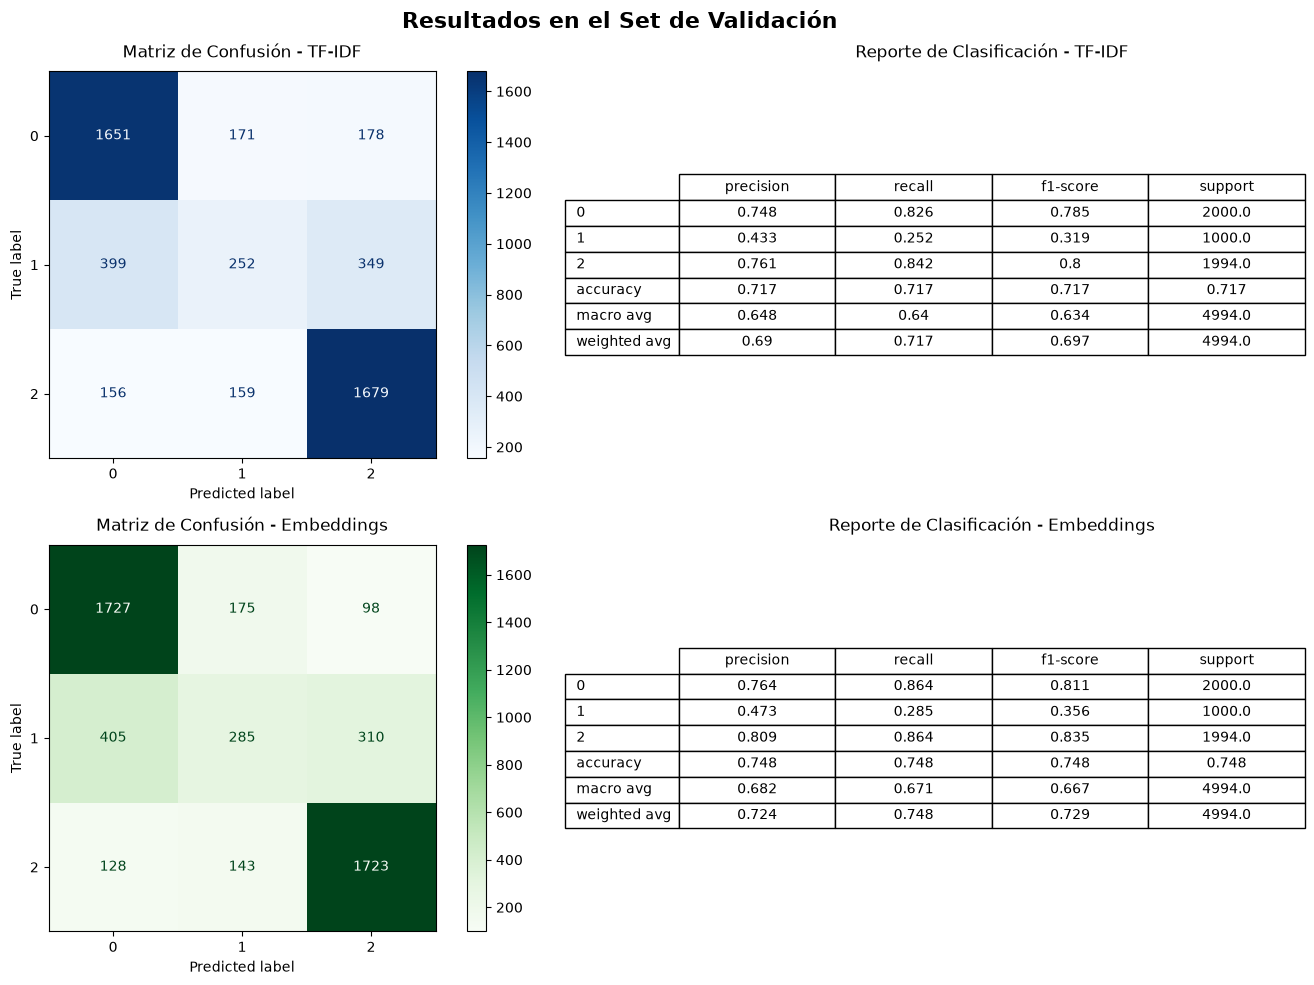

In [16]:
graficar_comparativa_modelos(
    lista_matrices=matrices_confusion_validation,
    lista_reportes=reportes_clasificacion_validation,
    nombres_modelos=["TF-IDF", "Embeddings"],
    titulo_general="Resultados en el Set de Validación"
)

## Conclusión Set de Validación - Matrices de confusión y Reportes de clasificación
#### Matriz de confusion
* El modelo Embeddings tuvo mayor cantidad de aciertos en todas las clases, frente al modelo TF-IDF, lo que indica un mejor desempeño de clasificación frente al modelo TF-IDF
#### Reporte de clasificación
* Ambos modelos presentan un rendimiento decente al predecir las clases 0 y 2, pero también presentan dificultades al predecir la clase 1. Esta dificultad puede estar relacionada con la ambigüedad presente en el lenguaje humano
* El modelo basado en Embeddings mejora la identificación de la clase 1 respecto a TF-IDF, obteniendo una precisión de 47.3% frente al 43.3%, lo que representa una diferencia de 4 puntos porcentuales. Sin embargo, ambos modelos continúan presentando dificultades para identificar correctamente esta clase.

# Revisando Sobreajuste

In [17]:
reportes_clasificacion_train , matrices_confusion_train, metricas_train_modelos = metricas_clasificacion(X_tfidf= X_train_tfidf, X_embeddings= X_train_embeddings, y= y_train)
metricas_train = pd.concat(objs= metricas_train_modelos, axis=0).T

In [18]:
metricas_train

,Regresion Logistica TF-IDF,Regresion logisitca Embeddings
Exactitud,0.770012,0.756879
Precision_macro,0.729953,0.694185
F1_macro,0.702130,0.677458
Recall_macro,0.700250,0.680429
ROC_auc_ovc,0.899317,0.883062
Perdida_brier_score_0,0.103441,0.106313
Perdida_brier_score_1,0.123485,0.134731
Perdida_brier_score_2,0.094698,0.091520
Coeficiente_matthew,0.637025,0.615776


## Conclusión Set de train - Tabla de Métricas
* El modelo TF-IDF presenta una mayor señal de sobre ajuste con respecto al modelo Embeddings, esto se da a notar en su diferencia en las métricas, siendo las de train mucho más altas que las de Validation. Por otra parte, el modelo Embeddings, presenta muy poca diferencia con respecto a Train, lo que indica un menor sobre ajuste y que si es capaz de rendir bien frente a datos nuevos

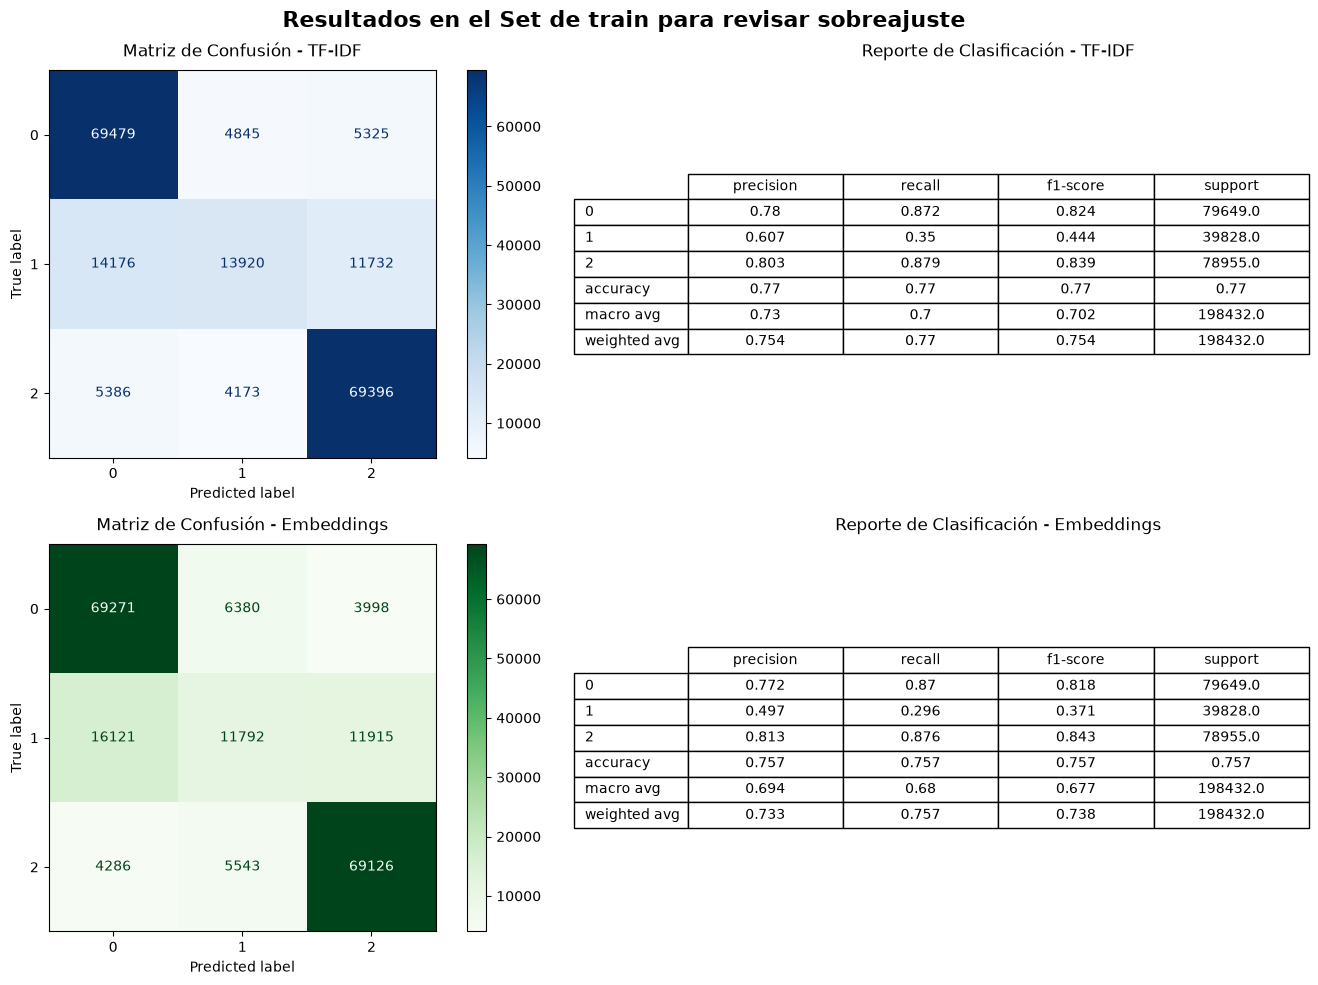

In [19]:
graficar_comparativa_modelos(
    lista_matrices=matrices_confusion_train,
    lista_reportes=reportes_clasificacion_train,
    nombres_modelos=["TF-IDF", "Embeddings"],
    titulo_general="Resultados en el Set de train para revisar sobreajuste"
)

## Conclusión Set de Validación - Matrices de confusión y Reportes de clasificación
#### Matriz de confusion
* El modelo TF-IDF parece ser mucho mejor prediciendo la clase 1, pero esto solo indica sobre ajuste, ya que al probar con nuevos datos, su rendimiento en esta clase baja mucho, incluso inferior al modelo Embeddings
#### Reporte de clasificación
* El modelo TF-IDF presenta un sobre ajuste en la clase 1 (La clase más difícil de predecir), ya que con los mismos datos parece tener un rendimiento superior, pero con datos nuevos, tiende a bajar su rendimiento.

# Métricas Test

In [20]:
reportes_clasificacion_test, matrices_confusion_test, metricas_test_modelos = metricas_clasificacion(X_tfidf= X_test_tfidf, X_embeddings= X_test_embeddings, y= y_test)
metricas_test = pd.concat(objs= metricas_test_modelos, axis=0).T

In [21]:
metricas_test

,Regresion Logistica TF-IDF,Regresion logisitca Embeddings
Exactitud,0.710136,0.761819
Precision_macro,0.634963,0.701984
F1_macro,0.626124,0.684739
Recall_macro,0.632216,0.686627
ROC_auc_ovc,0.844241,0.884379
Perdida_brier_score_0,0.123245,0.105308
Perdida_brier_score_1,0.148987,0.133927
Perdida_brier_score_2,0.116300,0.091971
Coeficiente_matthew,0.540035,0.623583


## Conclusión Set de testeo- Tabla de Métricas
* En términos de rendimiento global de clasificación, el modelo basado en Embeddings es superior al modelo TF-IDF
* El modelo basado en Embeddings tiende a ser más preciso en sus predicciones de todas sus clases
* El modelo basado en Embeddings tiende a tener un recall más alto en todas sus clases
* El modelo basado en Embeddings con su F1-score mejora frente al modelo TF-IDF
* En su perdida de brier, el modelo basado en Embeddings presenta predicciones más confiables que el modelo TF-IDF, en especial en la clase 2, aunque en la clase 1 están muy igualadas
* Según el coeficiente de matthew, ambos modelos presentan un buen desempeño de clasificación. Sin embargo, el modelo Embeddings obtiene un mejor resultado que TF-IDF, indicando una mayor correspondencia entre las predicciones realizadas y las clases reales.

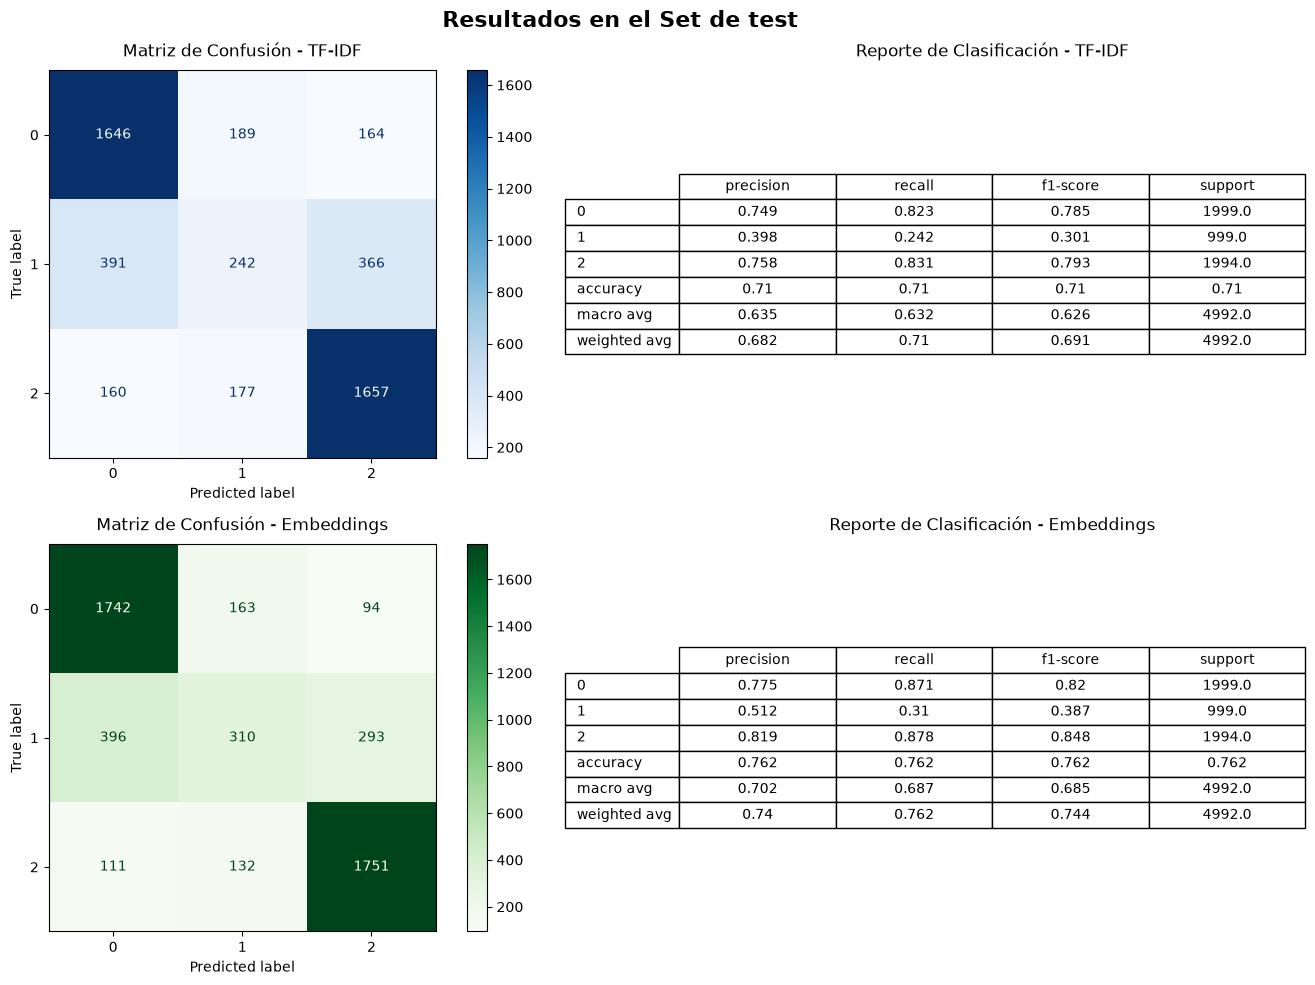

In [22]:
graficar_comparativa_modelos(
    lista_matrices=matrices_confusion_test,
    lista_reportes=reportes_clasificacion_test,
    nombres_modelos=["TF-IDF", "Embeddings"],
    titulo_general="Resultados en el Set de test"
)

## Conclusión Set de testeo - Matrices de confusión y Reportes de clasificación
#### Matriz de confusion
* El modelo Embeddings tuvo mayor cantidad de aciertos en todas las clases, frente al modelo TF-IDF, lo que indica un mejor desempeño de clasificación
#### Reporte de clasificación
* Ambos modelos presentan un rendimiento decente al predecir las clases 0 y 2, pero también presentan dificultades al predecir la clase 1. Esta dificultad puede estar relacionada con la ambigüedad presente en el lenguaje humano
* El modelo basado en Embeddings mejora la identificación de la clase 1 respecto a TF-IDF. Sin embargo, ambos modelos continúan presentando dificultades para identificar correctamente esta clase.

In [ ]:
# Extraer el estimador puro de Scikit-learn (desenvolver el proxy de cuML)
modelo_tfidf_cpu = getattr(modelo_tfidf, "_cpu", modelo_tfidf)
modelo_embeddings_cpu = getattr(modelo_embeddings, "_cpu", modelo_embeddings)

# Guardar los modelos limpios
sio.dump(modelo_tfidf_cpu, ruta_base / "Modelos Finales/modelo_tfidf.skops")
sio.dump(modelo_embeddings_cpu, ruta_base / "Modelos Finales/modelo_embeddings.skops")